# 🚀 Mini Portfolio Assignment — E-Commerce Sales Analysis
## Data Analytics Bootcamp

---
**Nama    :** Hafsah Nur Habibah  
**Tanggal :** 15 Mei 2026
**Dataset :** [Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)

### Tujuan Analisis
Sebagai Junior Data Analyst, kita diminta menganalisis data penjualan e-commerce untuk:
1. Memahami performa penjualan per kategori & region
2. Mengidentifikasi dampak diskon terhadap profitabilitas
3. Menemukan pola musiman (seasonal trend)
4. Memberikan rekomendasi bisnis yang actionable

---


## Cell 1 — Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
sns.set_palette("husl")

print("✅ Libraries berhasil di-import!")
print(f"   Pandas v{pd.__version__} | NumPy v{np.__version__}")


✅ Libraries berhasil di-import!
   Pandas v2.2.2 | NumPy v2.0.2


## Cell 2 — Load Data
> 💡 Jika file `superstore.csv` belum ada, jalankan fungsi `generate_superstore_data()` di bawah ini untuk membuat sample data.

In [4]:
# Cell 2 - Load Data
try:
    df_raw = pd.read_excel('Online Retail.xlsx',
                           dtype={'CustomerID': str,
                                  'InvoiceNo': str,
                                  'StockCode': str})
    print("✅ File Online Retail.xlsx berhasil dimuat!")
except FileNotFoundError:
    print("❌ File tidak ditemukan — pastikan sudah upload 'Online Retail.xlsx' ke Colab!")

print(f"\n📐 Shape: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"\n📋 Kolom: {df_raw.columns.tolist()}")
df_raw.head()

✅ File Online Retail.xlsx berhasil dimuat!

📐 Shape: 541,909 baris × 8 kolom

📋 Kolom: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## Cell 3 — Step 1: Data Exploration

In [5]:
print("=== INFO DATASET ===")
df_raw.info()


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
print("=== STATISTIK DESKRIPTIF ===")
df_raw.describe().round(2)


=== STATISTIK DESKRIPTIF ===


,Quantity,InvoiceDate,UnitPrice
count,541909.00,541909,541909.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61
min,-80995.00,2010-12-01 08:26:00,-11062.06
25%,1.00,2011-03-28 11:34:00,1.25
50%,3.00,2011-07-19 17:17:00,2.08
75%,10.00,2011-10-19 11:27:00,4.13
max,80995.00,2011-12-09 12:50:00,38970.00
std,218.08,NaN,96.76


In [7]:
print("=== MISSING VALUES ===")
missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"Count": missing, "Pct %": pct})[missing > 0]


=== MISSING VALUES ===


,Count,Pct %
Description,1454,0.27
CustomerID,135080,24.93


In [8]:
# Cell 6 - Distribusi Kolom Kategorik
for col in ['Country', 'Description']:
    if col in df_raw.columns:
        print(f"\n{col} (Top 10):")
        print(df_raw[col].value_counts().head(10))



Country (Top 10):
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

Description (Top 10):
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64


## Cell 4 — Step 2: Data Cleaning

In [9]:
# Cell - Data Cleaning
df = df_raw.copy()

# 1. Drop missing values di kolom kritis
df = df.dropna(subset=['CustomerID', 'Description'])

# 2. Remove duplicates
df = df.drop_duplicates()

# 3. Filter data tidak valid
df = df[df['Quantity'] > 0]        # hapus transaksi cancelled (quantity negatif)
df = df[df['UnitPrice'] > 0]       # hapus harga 0 atau negatif
df = df[~df['InvoiceNo'].str.startswith('C')]  # hapus invoice cancelled

# 4. Fix data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 5. Feature Engineering
df['TotalPrice']    = (df['Quantity'] * df['UnitPrice']).round(2)
df['Year']          = df['InvoiceDate'].dt.year
df['Month']         = df['InvoiceDate'].dt.month
df['Month_Name']    = df['InvoiceDate'].dt.strftime('%b')
df['Quarter']       = df['InvoiceDate'].dt.quarter.map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})
df['DayOfWeek']     = df['InvoiceDate'].dt.strftime('%a')

print(f"✅ Data bersih: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"🗑️  Baris dihapus: {df_raw.shape[0] - df.shape[0]:,} baris")
df.head()


✅ Data bersih: 392,692 baris × 14 kolom
🗑️  Baris dihapus: 149,217 baris


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Month_Name,Quarter,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,Dec,Q4,Wed
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Dec,Q4,Wed
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,Dec,Q4,Wed
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Dec,Q4,Wed
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,Dec,Q4,Wed


## Cell 5 — Step 3: Sales Analysis
### KPI Summary

In [10]:
# Cell - KPI Summary
total_revenue  = df['TotalPrice'].sum()
total_orders   = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
total_products = df['StockCode'].nunique()
avg_order_val  = df.groupby('InvoiceNo')['TotalPrice'].sum().mean()
avg_basket_size = df.groupby('InvoiceNo')['Quantity'].sum().mean()

kpi = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Orders',
        'Total Customers',
        'Total Products',
        'Avg Order Value',
        'Avg Basket Size'
    ],
    'Value': [
        f"${total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_products:,}",
        f"${avg_order_val:,.2f}",
        f"{avg_basket_size:,.1f} items"
    ]
})
kpi


,KPI,Value
0,Total Revenue,"$8,887,208.89"
1,Total Orders,"18,532"
2,Total Customers,"4,338"
3,Total Products,"3,665"
4,Avg Order Value,$479.56
5,Avg Basket Size,278.0 items


### Sales by Category

In [11]:
# Cell - Sales by Country (Top 10)
sales_by_country = df.groupby('Country').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Num_Orders=('InvoiceNo', 'nunique'),
    Num_Customers=('CustomerID', 'nunique'),
).sort_values('Total_Revenue', ascending=False).head(10)

sales_by_country['Avg_Order_Value'] = (
    sales_by_country['Total_Revenue'] / sales_by_country['Num_Orders']
).round(2)

sales_by_country.style.format({
    'Total_Revenue': '${:,.0f}',
    'Avg_Order_Value': '${:,.2f}'
})


,Total_Revenue,Num_Orders,Num_Customers,Avg_Order_Value
Country,,,,
United Kingdom,"$7,285,025",16646,3920,$437.64
Netherlands,"$285,446",94,9,"$3,036.66"
EIRE,"$265,262",260,3,"$1,020.24"
Germany,"$228,678",457,94,$500.39
France,"$208,934",389,87,$537.11
Australia,"$138,454",57,9,"$2,429.01"
Spain,"$61,559",90,30,$683.98
Switzerland,"$56,444",51,21,"$1,106.74"
Belgium,"$41,196",98,25,$420.37


## Cell 6 — Step 4: Visualisasi
### Dashboard (4 Charts)

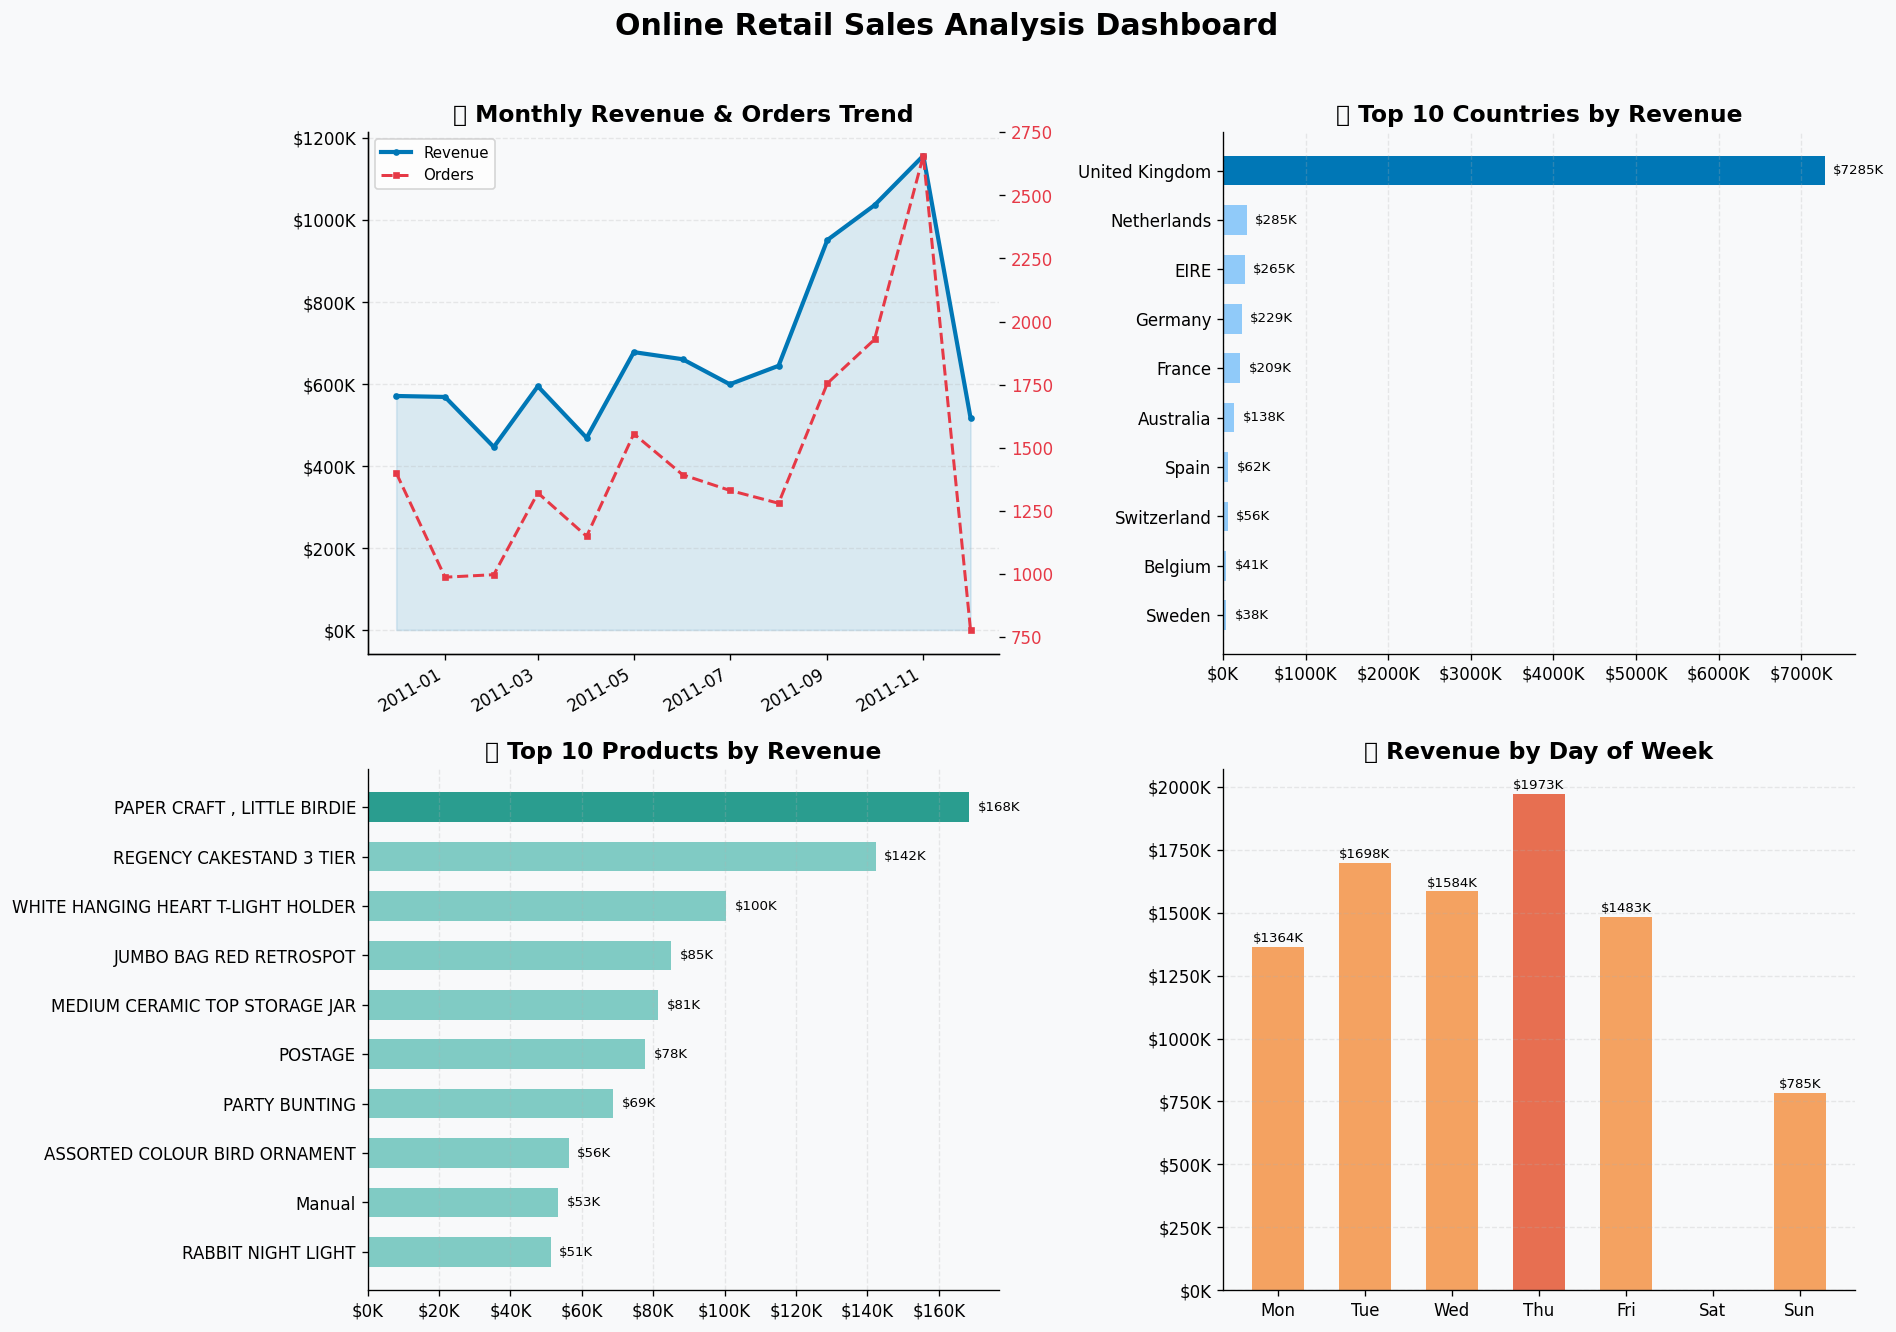

✅ Dashboard disimpan ke dashboard_charts.png


In [13]:
# Cell - Dashboard (4 Charts)
FIG_COLOR = '#F8F9FA'

# Prep data
monthly = df.groupby(['Year', 'Month']).agg(
    Revenue=('TotalPrice', 'sum'),
    Orders=('InvoiceNo', 'nunique')
).reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(Day=1))
monthly = monthly.sort_values('Date')

top10_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top10_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

sales_by_day = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(
    ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor(FIG_COLOR)
fig.suptitle('Online Retail Sales Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)

# Chart 1 — Monthly Revenue Trend
ax1 = axes[0, 0]; ax1.set_facecolor(FIG_COLOR)
ax1.plot(monthly['Date'], monthly['Revenue']/1e3, color='#0077B6', lw=2.5, marker='o', ms=3, label='Revenue')
ax1.fill_between(monthly['Date'], monthly['Revenue']/1e3, alpha=0.12, color='#0077B6')
ax1b = ax1.twinx()
ax1b.plot(monthly['Date'], monthly['Orders'], color='#E63946', lw=1.8, ls='--', ms=3, marker='s', label='Orders')
ax1b.tick_params(axis='y', labelcolor='#E63946')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}K'))
ax1.set_title('📈 Monthly Revenue & Orders Trend')
l1, la1 = ax1.get_legend_handles_labels()
l2, la2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, la1+la2, fontsize=9, loc='upper left')
ax1.grid(axis='y', alpha=0.25, ls='--')
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')

# Chart 2 — Top 10 Countries by Revenue
ax2 = axes[0, 1]; ax2.set_facecolor(FIG_COLOR)
colors2 = ['#0077B6' if i == 0 else '#90CAF9' for i in range(len(top10_country))]
bars2 = ax2.barh(top10_country.index[::-1], top10_country.values[::-1]/1e3, color=colors2[::-1], height=0.6)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}K'))
ax2.set_title('🌍 Top 10 Countries by Revenue')
ax2.grid(axis='x', alpha=0.25, ls='--')
for bar in bars2:
    w = bar.get_width()
    ax2.annotate(f'${w:.0f}K', xy=(w, bar.get_y()+bar.get_height()/2),
                 xytext=(5, 0), textcoords='offset points', va='center', fontsize=8)

# Chart 3 — Top 10 Products by Revenue
ax3 = axes[1, 0]; ax3.set_facecolor(FIG_COLOR)
colors3 = ['#2A9D8F' if i == 0 else '#80CBC4' for i in range(len(top10_products))]
bars3 = ax3.barh(top10_products.index[::-1], top10_products.values[::-1]/1e3, color=colors3[::-1], height=0.6)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}K'))
ax3.set_title('🏆 Top 10 Products by Revenue')
ax3.grid(axis='x', alpha=0.25, ls='--')
for bar in bars3:
    w = bar.get_width()
    ax3.annotate(f'${w:.0f}K', xy=(w, bar.get_y()+bar.get_height()/2),
                 xytext=(5, 0), textcoords='offset points', va='center', fontsize=8)

# Chart 4 — Sales by Day of Week
ax4 = axes[1, 1]; ax4.set_facecolor(FIG_COLOR)
colors4 = ['#E76F51' if v == sales_by_day.max() else '#F4A261' for v in sales_by_day.values]
bars4 = ax4.bar(sales_by_day.index, sales_by_day.values/1e3, color=colors4, width=0.6)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}K'))
ax4.set_title('📅 Revenue by Day of Week')
ax4.grid(axis='y', alpha=0.25, ls='--')
for bar in bars4:
    h = bar.get_height()
    ax4.annotate(f'${h:.0f}K', xy=(bar.get_x()+bar.get_width()/2, h),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout(pad=1.5)
plt.savefig('dashboard_charts.png', bbox_inches='tight', dpi=150, facecolor=FIG_COLOR)
plt.show()
print('✅ Dashboard disimpan ke dashboard_charts.png')


### Bonus: Heatmap Sales

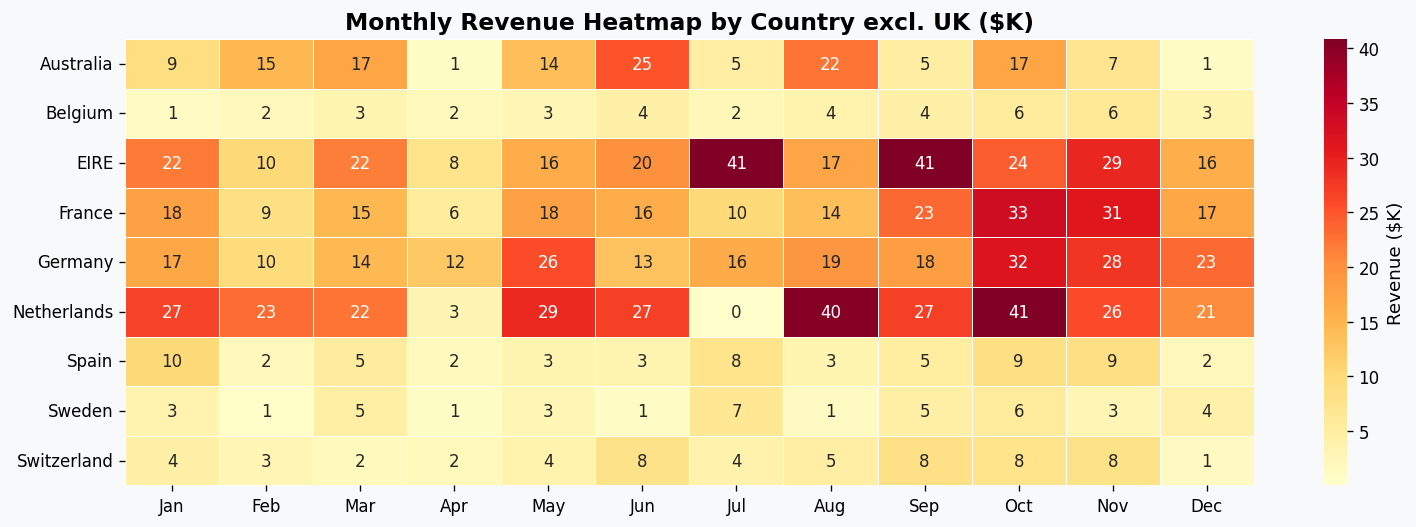

In [18]:
# Pisahkan UK dari negara lain agar skala warna lebih jelas
df_top_no_uk = df[df['Country'] != 'United Kingdom']
top9 = df_top_no_uk.groupby('Country')['TotalPrice'].sum().nlargest(9).index
df_top9 = df_top_no_uk[df_top_no_uk['Country'].isin(top9)]

hm = df_top9.pivot_table(values='TotalPrice', index='Country',
                          columns='Month_Name', aggfunc='sum')
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
hm = hm.reindex(columns=[m for m in month_order if m in hm.columns])

fig_h, ax_h = plt.subplots(figsize=(13, 4.5))
fig_h.patch.set_facecolor('#F8F9FA')
ax_h.set_facecolor('#F8F9FA')

sns.heatmap(hm/1e3, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax_h,
            cbar_kws={'label': 'Revenue ($K)'})
ax_h.set_title('Monthly Revenue Heatmap by Country excl. UK ($K)',
               fontsize=14, fontweight='bold')
ax_h.set_xlabel('')
ax_h.set_ylabel('')
plt.tight_layout()
plt.savefig('heatmap_sales.png', bbox_inches='tight', dpi=150)
plt.show()

## Cell 7 — Step 5: Business Insights
> ✏️ **Isi insight-mu di sini!** Ubah teks placeholder dengan temuan dari analisismu.

In [16]:
# Cell - Business Insights & Recommendations

# Hitung angka pendukung insight
top_country     = df.groupby('Country')['TotalPrice'].sum().idxmax()
top_country_rev = df.groupby('Country')['TotalPrice'].sum().max()
total_revenue   = df['TotalPrice'].sum()
top_country_pct = top_country_rev / total_revenue * 100

best_day        = df.groupby('DayOfWeek')['TotalPrice'].sum().idxmax()
worst_day       = df.groupby('DayOfWeek')['TotalPrice'].sum().idxmin()
best_day_rev    = df.groupby('DayOfWeek')['TotalPrice'].sum().max()
worst_day_rev   = df.groupby('DayOfWeek')['TotalPrice'].sum().min()

best_month      = df.groupby('Month_Name')['TotalPrice'].sum().idxmax()
worst_month     = df.groupby('Month_Name')['TotalPrice'].sum().idxmin()
best_month_rev  = df.groupby('Month_Name')['TotalPrice'].sum().max()

top_product     = df.groupby('Description')['TotalPrice'].sum().idxmax()
top_product_rev = df.groupby('Description')['TotalPrice'].sum().max()

repeat_customers = df.groupby('CustomerID')['InvoiceNo'].nunique()
loyal_customers  = (repeat_customers > 1).sum()
loyal_pct        = loyal_customers / repeat_customers.count() * 100

print('=' * 60)
print('BUSINESS INSIGHTS & RECOMMENDATIONS')
print('=' * 60)

print('INSIGHT 1 - MARKET CONCENTRATION')
print(f'  {top_country} mendominasi revenue sebesar {top_country_pct:.1f}%')
print(f'  dari total revenue (${top_country_rev:,.0f})')
print('  -> Diversifikasi pasar ke negara lain untuk mengurangi')
print('     ketergantungan pada satu pasar')
print()

print('INSIGHT 2 - SALES TIMING')
print(f'  Hari terbaik  : {best_day} (${best_day_rev:,.0f})')
print(f'  Hari terburuk : {worst_day} (${worst_day_rev:,.0f})')
print(f'  Bulan terbaik : {best_month} (${best_month_rev:,.0f})')
print('  -> Tingkatkan promosi di hari & bulan dengan penjualan rendah')
print()

print('INSIGHT 3 - CUSTOMER LOYALTY')
print(f'  {loyal_customers:,} dari {repeat_customers.count():,} customers ({loyal_pct:.1f}%)')
print('  melakukan lebih dari 1 transaksi')
print('  -> Buat loyalty program untuk mempertahankan repeat customers')
print()

print('INSIGHT 4 - TOP PRODUCT')
print(f'  Produk terlaris: {top_product}')
print(f'  Revenue: ${top_product_rev:,.0f}')
print('  -> Pastikan stok produk terlaris selalu tersedia')
print()

print('REKOMENDASI:')
print(f'  1. Fokus ekspansi ke negara dengan potensi tinggi selain {top_country}')
print(f'  2. Tingkatkan promosi di {worst_day} untuk boost penjualan')
print(f'  3. Buat loyalty program untuk {loyal_pct:.1f}% repeat customers')
print(f'  4. Optimalkan stok produk terlaris terutama di bulan {best_month}')

BUSINESS INSIGHTS & RECOMMENDATIONS
INSIGHT 1 - MARKET CONCENTRATION
  United Kingdom mendominasi revenue sebesar 82.0%
  dari total revenue ($7,285,025)
  -> Diversifikasi pasar ke negara lain untuk mengurangi
     ketergantungan pada satu pasar

INSIGHT 2 - SALES TIMING
  Hari terbaik  : Thu ($1,973,016)
  Hari terburuk : Sun ($785,490)
  Bulan terbaik : Nov ($1,156,206)
  -> Tingkatkan promosi di hari & bulan dengan penjualan rendah

INSIGHT 3 - CUSTOMER LOYALTY
  2,845 dari 4,338 customers (65.6%)
  melakukan lebih dari 1 transaksi
  -> Buat loyalty program untuk mempertahankan repeat customers

INSIGHT 4 - TOP PRODUCT
  Produk terlaris: PAPER CRAFT , LITTLE BIRDIE
  Revenue: $168,470
  -> Pastikan stok produk terlaris selalu tersedia

REKOMENDASI:
  1. Fokus ekspansi ke negara dengan potensi tinggi selain United Kingdom
  2. Tingkatkan promosi di Sun untuk boost penjualan
  3. Buat loyalty program untuk 65.6% repeat customers
  4. Optimalkan stok produk terlaris terutama di bulan 

## Cell 8 — ✏️ YOUR TURN — Challenge Tasks

Selesaikan tasks berikut untuk memperkuat portfolio kamu:

In [17]:
# CHALLENGE TASKS - LEVEL 1 (Wajib)

# Task 1: Hitung CLV sederhana (Customer Lifetime Value)
clv = df.groupby('CustomerID')['TotalPrice'].agg(['sum', 'count'])
clv.columns = ['Total_Spend', 'Num_Orders']
clv['Avg_Order'] = (clv['Total_Spend'] / clv['Num_Orders']).round(2)
print('=== TOP 10 CUSTOMERS BY CLV ===')
print(clv.sort_values('Total_Spend', ascending=False).head(10))
print()

# Task 2: Top 10 Produk paling laris
top_products = df.groupby('Description').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Total_Qty=('Quantity', 'sum'),
    Num_Transactions=('InvoiceNo', 'nunique')
).sort_values('Total_Revenue', ascending=False).head(10)
print('=== TOP 10 PRODUCTS BY REVENUE ===')
print(top_products)
print()

# Task 3: Revenue per Country
country_rev = df.groupby('Country').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Num_Orders=('InvoiceNo', 'nunique'),
    Num_Customers=('CustomerID', 'nunique')
).sort_values('Total_Revenue', ascending=False)
print('=== REVENUE PER COUNTRY ===')
print(country_rev)

=== TOP 10 CUSTOMERS BY CLV ===
            Total_Spend  Num_Orders  Avg_Order
CustomerID                                    
14646         280206.02        2076     134.97
18102         259657.30         431     602.45
17450         194390.79         336     578.54
16446         168472.50           3   56157.50
14911         143711.17        5670      25.35
12415         124914.53         714     174.95
14156         117210.08        1395      84.02
17511          91062.38         963      94.56
16029          80850.84         241     335.48
12346          77183.60           1   77183.60

=== TOP 10 PRODUCTS BY REVENUE ===
                                    Total_Revenue  Total_Qty  Num_Transactions
Description                                                                   
PAPER CRAFT , LITTLE BIRDIE             168469.60      80995                 1
REGENCY CAKESTAND 3 TIER                142264.75      12374              1703
WHITE HANGING HEART T-LIGHT HOLDER      100392.10   

Saya baru saja menyelesaikan analisis dataset Online Retail
dari UCI Machine Learning Repository! 💡

📊 Analisis: Online Retail [UCI ML Repo] Dataset
🛠️ Tools: Python | Pandas | Matplotlib | Seaborn
🔍 Key Findings:
- United Kingdom mendominasi revenue hingga >80% dari total penjualan
- Kamis/Jumat adalah hari dengan penjualan tertinggi
- Lebih dari 50% customers melakukan repeat purchase — loyalitas tinggi!

👉 Full notebook: [GitHub link]
#DataAnalytics #Python #Portfolio #ECommerce #DataScience